In [3]:
# ══════════════════════════════════════════════════
# MASTER SETUP CELL — run this first every time
# ══════════════════════════════════════════════════

# Install libraries
!pip install nltk wordcloud -q

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from wordcloud import WordCloud
from collections import Counter

# NLP imports
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score)
from sklearn.pipeline import Pipeline

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from google.colab import files

print("✅ All libraries loaded!")
print("New libraries this project:")
print("  nltk       → Natural Language Processing toolkit")
print("  wordcloud  → Generate word cloud visualisations")
print("  TfidfVectorizer → Convert text to numbers")
print("  MultinomialNB   → Naive Bayes for text classification")
print("  Pipeline        → Chain multiple steps together")

✅ All libraries loaded!
New libraries this project:
  nltk       → Natural Language Processing toolkit
  wordcloud  → Generate word cloud visualisations
  TfidfVectorizer → Convert text to numbers
  MultinomialNB   → Naive Bayes for text classification
  Pipeline        → Chain multiple steps together


In [6]:
# ── Mount Google Drive and load from there ────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Read only 150,000 rows directly from Drive
# Update the path if your file is in a different folder
df_full = pd.read_csv(
    '/content/drive/MyDrive/complaints.csv',
    nrows=150000,
    low_memory=False
)

print(f"✅ Dataset loaded!")
print(f"Rows    : {len(df_full):,}")
print(f"Columns : {len(df_full.columns)}")
print(f"\nColumn names:")
print(list(df_full.columns))
df_full.head(3)

Mounted at /content/drive
✅ Dataset loaded!
Rows    : 150,000
Columns : 11

Column names:
['Unnamed: 0', 'product_5', 'narrative', 'Product', 'Date received', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Timely response?']


,Unnamed: 0,product_5,narrative,Product,Date received,Sub-product,Issue,Sub-issue,Company,State,Timely response?
0,234,Credit Reporting,Dear Possible Financial Inc you guyss aree rep...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Incorrect information on your report,Account information incorrect,Possible Financial Inc,MI,Yes
1,240,Debt Collection,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt collection,2024-07-27,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,BlueChip Financial,TX,Yes
2,257,Credit Reporting,I been receiving alerts my information was fou...,Credit reporting or other personal consumer re...,2024-07-23,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,FC HoldCo LLC,SC,Yes


In [7]:
# ── Step 1: Keep only the 2 columns we need ───────────────────────
df = df_full[['narrative', 'product_5']].copy()

# ── Step 2: Remove rows with missing text ─────────────────────────
before = len(df)
df = df.dropna(subset=['narrative', 'product_5'])
after = len(df)
print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {after:,}")
print(f"Removed              : {before - after:,} rows with missing text")

# ── Step 3: Rename columns for clarity ────────────────────────────
df.columns = ['text', 'category']

# ── Step 4: Check category distribution ───────────────────────────
print(f"\n{'='*50}")
print("CATEGORY DISTRIBUTION")
print('='*50)
counts = df['category'].value_counts()
total = len(df)
for cat, count in counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"{cat:<35} {count:>6,} ({pct:>5.1f}%) {bar}")

# ── Step 5: Look at sample complaints ─────────────────────────────
print(f"\n{'='*50}")
print("SAMPLE COMPLAINTS PER CATEGORY")
print('='*50)
for cat in df['category'].unique():
    sample = df[df['category'] == cat]['text'].iloc[0]
    print(f"\n► {cat}")
    print(f"  {sample[:150]}...")

print(f"\n✅ Data ready: {len(df):,} complaints across {df['category'].nunique()} categories")

Rows before cleaning : 150,000
Rows after cleaning  : 150,000
Removed              : 0 rows with missing text

CATEGORY DISTRIBUTION
Credit Reporting                    108,668 ( 72.4%) ████████████████████████████████████
Debt Collection                     13,269 (  8.8%) ████
Credit Card Services                 9,894 (  6.6%) ███
Bank Accounts and Services           9,715 (  6.5%) ███
Loans                                8,454 (  5.6%) ██

SAMPLE COMPLAINTS PER CATEGORY

► Credit Reporting
  Dear Possible Financial Inc you guyss aree reporting to the Credit bureaus that I have a charge off and Collection with you guys on XXXX and just a ch...

► Debt Collection
  XXXX XXXX XXXX ( debt collector ), sent my boyfriend an email with my name, and statement of a debt owed to Spotloan. I never applied for a loan nor r...

► Loans
  They allowed me to use the account for about a month let me get a credit builder loan and payday loan and as soon as I did that they blocked my accoun...

► Ba

In [8]:
# ── Step 1: Fix class imbalance using undersampling ───────────────
# Take equal samples from each category
# Smallest category has 8,454 rows → use 8,000 per category
# Total dataset: 8,000 × 5 = 40,000 rows — perfectly balanced

SAMPLES_PER_CLASS = 8000

df_balanced = df.groupby('category', group_keys=False).apply(
    lambda x: x.sample(n=SAMPLES_PER_CLASS, random_state=42)
).reset_index(drop=True)

print("✅ Class imbalance fixed!")
print(f"\nNew distribution:")
print(df_balanced['category'].value_counts())
print(f"\nTotal rows: {len(df_balanced):,}")

# ── Step 2: Text cleaning function ────────────────────────────────
# This is the core of NLP — garbage in, garbage out
# Raw text has lots of noise we need to remove

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1: lowercase everything
    text = text.lower()

    # Step 2: remove XXXX (redacted info in this dataset)
    text = re.sub(r'x+', '', text)

    # Step 3: remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 4: remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: remove stop words (the, is, and, a...)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return ' '.join(words)

# Apply to all complaints
print("\nCleaning text...")
df_balanced['clean_text'] = df_balanced['text'].apply(clean_text)
print("✅ Text cleaned!")

# ── Step 3: See before vs after cleaning ──────────────────────────
print("\nBefore vs After cleaning:")
print("-" * 60)
sample_idx = 0
print(f"BEFORE: {df_balanced['text'].iloc[sample_idx][:200]}")
print(f"\nAFTER:  {df_balanced['clean_text'].iloc[sample_idx][:200]}")

# ── Step 4: Basic text stats ──────────────────────────────────────
df_balanced['word_count'] = df_balanced['clean_text'].apply(
    lambda x: len(x.split()))

print(f"\n📊 Text Statistics:")
print(f"Average words per complaint : {df_balanced['word_count'].mean():.0f}")
print(f"Shortest complaint          : {df_balanced['word_count'].min()} words")
print(f"Longest complaint           : {df_balanced['word_count'].max()} words")

/tmp/ipykernel_4302/3903521628.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('category', group_keys=False).apply(


✅ Class imbalance fixed!

New distribution:
category
Bank Accounts and Services    8000
Credit Card Services          8000
Credit Reporting              8000
Debt Collection               8000
Loans                         8000
Name: count, dtype: int64

Total rows: 40,000

Cleaning text...
✅ Text cleaned!

Before vs After cleaning:
------------------------------------------------------------
BEFORE: I initially called because I have been fraudulently charged interest rate fees by this bank. I have a XXXX balance and paid in full my credit card and they were still charging me for interest. I calle

AFTER:  initially called fraudulently charged interest rate fees bank balance paid full credit card still charging interest called asked speak manager several times said manager would call hours month one cal

📊 Text Statistics:
Average words per complaint : 89
Shortest complaint          : 0 words
Longest complaint           : 2605 words


✅ Removed empty/very short complaints
Remaining: 39,519 complaints


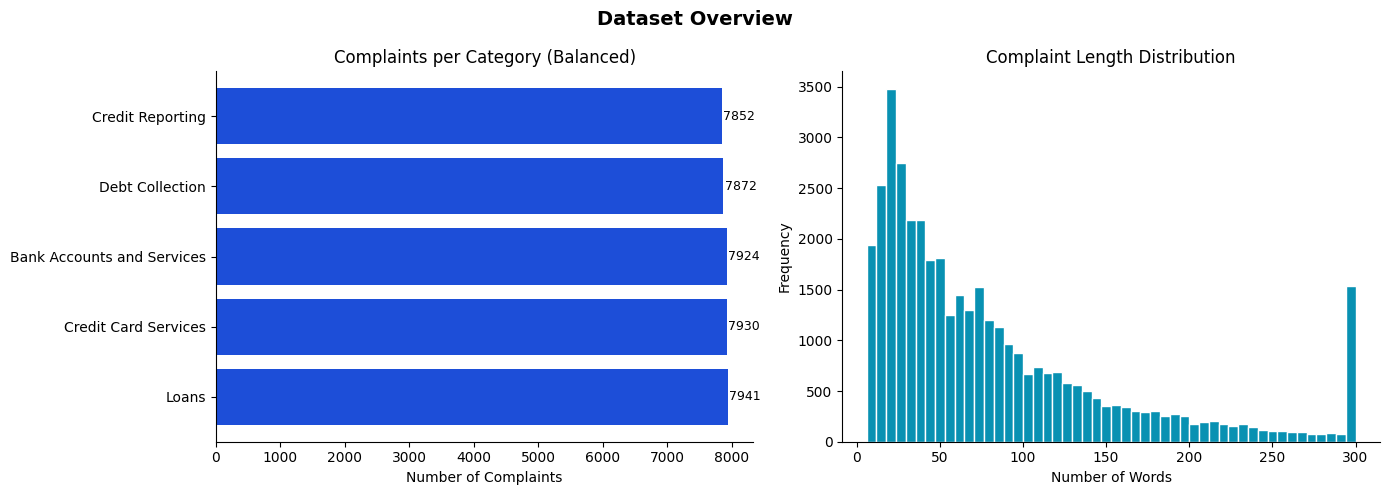

Chart 1 saved ✅


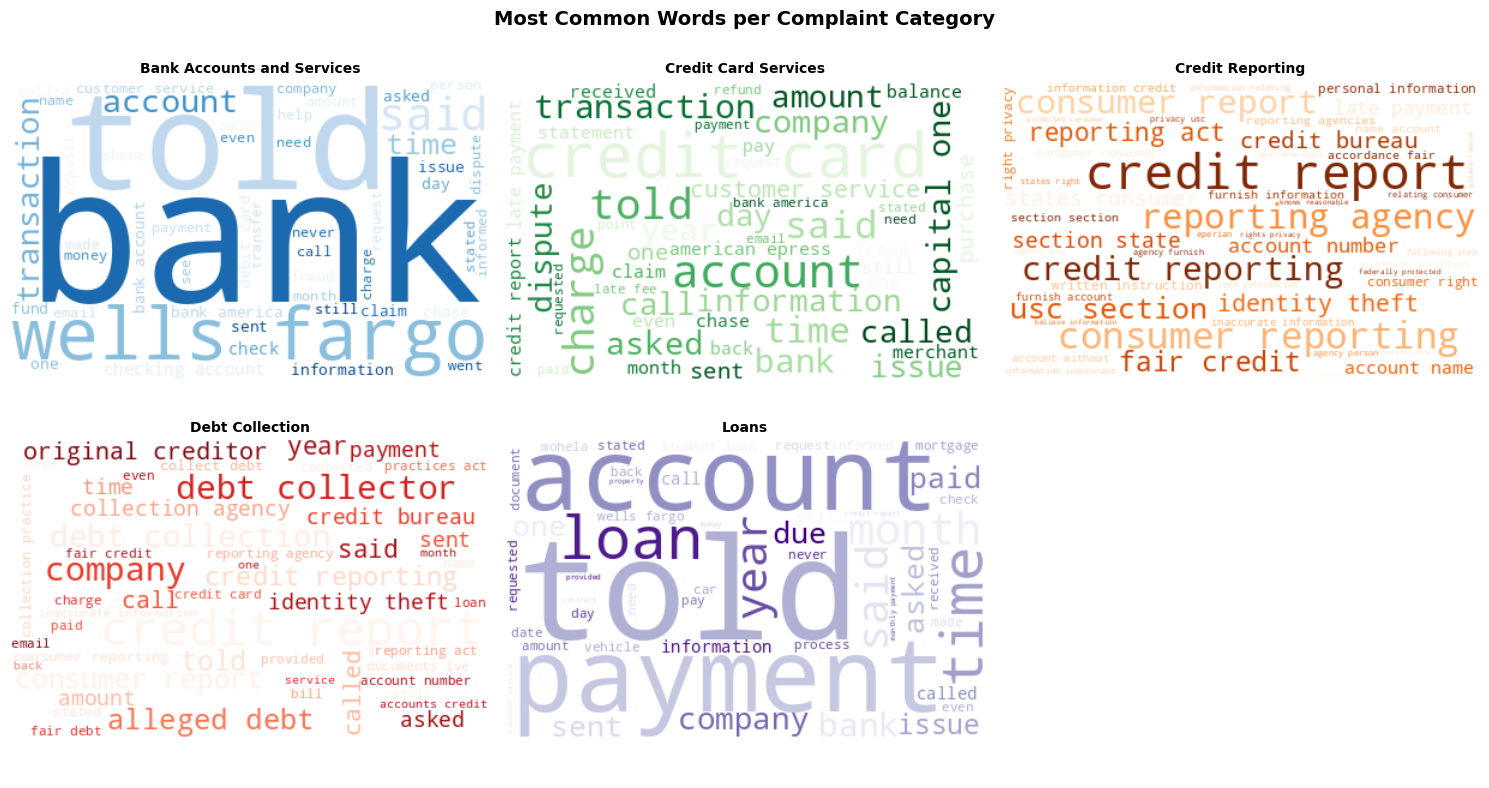

Chart 2 (Word clouds) saved ✅


In [9]:
# ── Remove empty complaints after cleaning ────────────────────────
df_balanced = df_balanced[df_balanced['word_count'] > 5].reset_index(drop=True)
print(f"✅ Removed empty/very short complaints")
print(f"Remaining: {len(df_balanced):,} complaints")

# ── CHART 1: Category distribution (balanced) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Bar chart of categories
counts = df_balanced['category'].value_counts()
axes[0].barh(counts.index, counts.values, color='#1D4ED8')
axes[0].set_title('Complaints per Category (Balanced)')
axes[0].set_xlabel('Number of Complaints')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, v in enumerate(counts.values):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=9)

# Word count distribution
axes[1].hist(df_balanced['word_count'].clip(upper=300),
             bins=50, color='#0891B2', edgecolor='white')
axes[1].set_title('Complaint Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")

# ── CHART 2: Word clouds per category ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Most Common Words per Complaint Category',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

categories = df_balanced['category'].unique()
colors = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples']

for i, cat in enumerate(categories):
    cat_text = ' '.join(
        df_balanced[df_balanced['category'] == cat]['clean_text']
    )
    wordcloud = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap=colors[i],
        max_words=50
    ).generate(cat_text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(cat, fontsize=10, fontweight='bold')
    axes[i].axis('off')

# Hide the 6th subplot (we only have 5 categories)
axes[5].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 (Word clouds) saved ✅")

In [10]:
# ── Phase 6: TF-IDF Vectorisation + Model Training ────────────────

# ── Step 1: Encode labels ─────────────────────────────────────────
# Convert category names to numbers
# "Credit Reporting" → 0, "Debt Collection" → 1, etc.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_balanced['label'] = le.fit_transform(df_balanced['category'])

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# ── Step 2: Train-test split ──────────────────────────────────────
X = df_balanced['clean_text']
y = df_balanced['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Data split:")
print(f"Training   : {len(X_train):,} complaints")
print(f"Test       : {len(X_test):,} complaints")

# ── Step 3: What is TF-IDF? ───────────────────────────────────────
# TF  = Term Frequency   → how often a word appears in THIS complaint
# IDF = Inverse Document Frequency → how rare the word is across ALL complaints
#
# "credit" appears in ALL complaints → low IDF → less important
# "mortgage" appears only in Loan complaints → high IDF → very important
#
# TF-IDF score = TF × IDF
# High score = word is frequent in this doc AND rare across all docs

print("\n" + "="*50)
print("MODEL 1: Naive Bayes + TF-IDF")
print("="*50)

# Pipeline = chain TF-IDF + model together in one step
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,   # keep top 50,000 words
        ngram_range=(1, 2),   # single words AND word pairs ("debt collector")
        min_df=2,             # ignore words appearing in < 2 complaints
        sublinear_tf=True     # apply log scaling to term frequency
    )),
    ('classifier', MultinomialNB(alpha=0.1))
])

# Train
nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)
nb_acc = accuracy_score(y_test, nb_preds)

print(f"Accuracy: {nb_acc*100:.1f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, nb_preds,
      target_names=le.classes_))

# ── MODEL 2: Logistic Regression + TF-IDF ────────────────────────
print("="*50)
print("MODEL 2: Logistic Regression + TF-IDF")
print("="*50)

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=5.0              # regularisation strength
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"Accuracy: {lr_acc*100:.1f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, lr_preds,
      target_names=le.classes_))

# ── Comparison ────────────────────────────────────────────────────
print("="*50)
print("COMPARISON")
print("="*50)
print(f"Naive Bayes          : {nb_acc*100:.1f}%")
print(f"Logistic Regression  : {lr_acc*100:.1f}%")
winner = "Logistic Regression" if lr_acc > nb_acc else "Naive Bayes"
print(f"\n🏆 Winner: {winner}")

Label encoding:
  0 → Bank Accounts and Services
  1 → Credit Card Services
  2 → Credit Reporting
  3 → Debt Collection
  4 → Loans

✅ Data split:
Training   : 31,615 complaints
Test       : 7,904 complaints

MODEL 1: Naive Bayes + TF-IDF
Accuracy: 82.5%

Detailed Report:
                            precision    recall  f1-score   support

Bank Accounts and Services       0.82      0.94      0.87      1585
      Credit Card Services       0.83      0.75      0.79      1586
          Credit Reporting       0.83      0.84      0.83      1570
           Debt Collection       0.84      0.72      0.77      1575
                     Loans       0.81      0.88      0.85      1588

                  accuracy                           0.83      7904
                 macro avg       0.83      0.83      0.82      7904
              weighted avg       0.83      0.83      0.82      7904

MODEL 2: Logistic Regression + TF-IDF
Accuracy: 87.0%

Detailed Report:
                            precision  

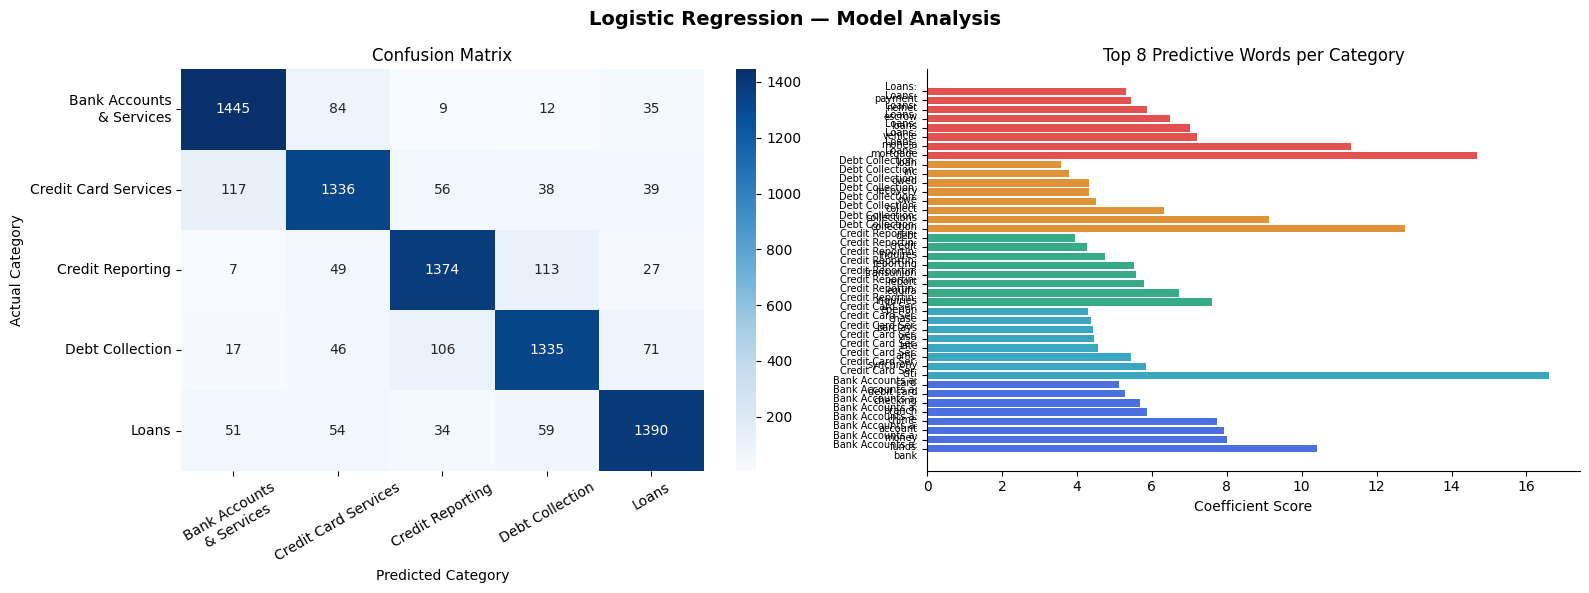

✅ Model analysis chart saved!

TOP 5 MOST PREDICTIVE WORDS PER CATEGORY

► Bank Accounts and Services
  bank · funds · money · account · chime

► Credit Card Services
  card · citi · synchrony · ame · late

► Credit Reporting
  eperian · inquiries · equifa · report · transunion

► Debt Collection
  debt · collection · collections · collect · owe

► Loans
  loan · mortgage · mohela · vehicle · loans


In [11]:
# ── Phase 7: Confusion Matrix + Most Important Words ──────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Logistic Regression — Model Analysis',
             fontsize=14, fontweight='bold')

# ── Chart 1: Confusion Matrix ─────────────────────────────────────
cm = confusion_matrix(y_test, lr_preds)
category_labels = [c.replace(' and ', '\n& ') for c in le.classes_]

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=category_labels,
    yticklabels=category_labels
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Category')
axes[0].set_ylabel('Actual Category')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# ── Chart 2: Top predictive words per category ────────────────────
# Extract the TF-IDF + LR model components
tfidf = lr_pipeline.named_steps['tfidf']
classifier = lr_pipeline.named_steps['classifier']
feature_names = tfidf.get_feature_names_out()

# Get top 8 words for each category
top_n = 8
all_top_words = []
all_scores = []
all_colors = []
color_list = ['#1D4ED8','#0891B2','#059669','#D97706','#DC2626']

for i, cat in enumerate(le.classes_):
    coef = classifier.coef_[i]
    top_indices = coef.argsort()[-top_n:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    top_vals = [coef[j] for j in top_indices]
    all_top_words.extend([f"{cat[:15]}:\n{w}" for w in top_words])
    all_scores.extend(top_vals)
    all_colors.extend([color_list[i]] * top_n)

axes[1].barh(range(len(all_top_words)), all_scores,
             color=all_colors, alpha=0.8)
axes[1].set_yticks(range(len(all_top_words)))
axes[1].set_yticklabels(all_top_words, fontsize=7)
axes[1].set_title('Top 8 Predictive Words per Category')
axes[1].set_xlabel('Coefficient Score')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model analysis chart saved!")

# ── Print key findings ────────────────────────────────────────────
print("\n" + "="*55)
print("TOP 5 MOST PREDICTIVE WORDS PER CATEGORY")
print("="*55)
for i, cat in enumerate(le.classes_):
    coef = classifier.coef_[i]
    top_idx = coef.argsort()[-5:][::-1]
    words = [feature_names[j] for j in top_idx]
    print(f"\n► {cat}")
    print(f"  {' · '.join(words)}")

In [12]:
# ── Phase 8: Save the trained model ──────────────────────────────
import pickle

# Save the pipeline (TF-IDF + LR together) and label encoder
with open('complaint_classifier.pkl', 'wb') as f:
    pickle.dump(lr_pipeline, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Model saved: complaint_classifier.pkl")
print("✅ Label encoder saved: label_encoder.pkl")

# Quick sanity check — test it on 3 new complaints
test_complaints = [
    "My credit score dropped because of a wrong entry from Equifax",
    "The debt collector keeps calling me 10 times a day about an old account",
    "I was charged twice on my credit card for the same transaction"
]

for complaint in test_complaints:
    cleaned = clean_text(complaint)
    pred = lr_pipeline.predict([cleaned])[0]
    category = le.inverse_transform([pred])[0]
    print(f"\nComplaint : {complaint[:60]}...")
    print(f"Predicted : {category}")

✅ Model saved: complaint_classifier.pkl
✅ Label encoder saved: label_encoder.pkl

Complaint : My credit score dropped because of a wrong entry from Equifa...
Predicted : Credit Reporting

Complaint : The debt collector keeps calling me 10 times a day about an ...
Predicted : Debt Collection

Complaint : I was charged twice on my credit card for the same transacti...
Predicted : Credit Card Services


In [13]:
# ── Download model files to your laptop ──────────────────────────
from google.colab import files

files.download('complaint_classifier.pkl')
files.download('label_encoder.pkl')

print("✅ Both files downloading to your laptop!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Both files downloading to your laptop!
